In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

In [6]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("PCA TUTORIAL WITH SKLEARN DATASETS")
print("="*80)

PCA TUTORIAL WITH SKLEARN DATASETS


In [7]:
print("\n" + "="*80)
print("EXAMPLE 1: IRIS DATASET")
print("="*80)

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: species (0, 1, 2)
feature_names = iris.feature_names
target_names = iris.target_names


EXAMPLE 1: IRIS DATASET


In [8]:
print(f"\nOriginal data shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")



Original data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [9]:
# Step 1: Standardize the features (important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nData after standardization (mean=0, std=1):")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}")



Data after standardization (mean=0, std=1):
Mean: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std: [1. 1. 1. 1.]


In [13]:
# Step 2: Apply PCA
pca = PCA(n_components=2)  # Reduce from 4D to 2D
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Results:")
print(f"Reduced data shape: {X_pca.shape}")
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nEigenvalues (variance): {pca.explained_variance_}")

# Step 3: Examine the principal components (eigenvectors)
print(f"\nPrincipal Components (Eigenvectors):")
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
)
print(components_df)


PCA Results:
Reduced data shape: (150, 2)

Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 95.81%

Eigenvalues (variance): [2.93808505 0.9201649 ]

Principal Components (Eigenvectors):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942


In [14]:
100-95.81

4.189999999999998

In [12]:
# The Iris dataset has only 4 features, so maximum n_components = 4
# If you set n_components > number of features, sklearn will automatically
# reduce it to the maximum possible

# Step 2: Apply PCA (corrected)
pca = PCA(n_components=4)  # Maximum is 4 since we have 4 features
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Results:")
print(f"Reduced data shape: {X_pca.shape}")
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nEigenvalues (variance): {pca.explained_variance_}")

# Step 3: Examine the principal components (eigenvectors)
print(f"\nPrincipal Components (Eigenvectors):")
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]  # Dynamic indexing
)
print(components_df)

# Interpretation of each component
print("\n" + "="*60)
print("INTERPRETATION OF PRINCIPAL COMPONENTS")
print("="*60)

for i, pc in enumerate(components_df.index):
    print(f"\n{pc} (explains {pca.explained_variance_ratio_[i]:.1%} of variance):")
    # Get the feature with highest absolute loading
    abs_loadings = components_df.loc[pc].abs()
    top_features = abs_loadings.nlargest(2)

    for feature in top_features.index:
        loading = components_df.loc[pc, feature]
        print(f"  - {feature}: {loading:+.3f} {'(positive)' if loading > 0 else '(negative)'}")

print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
print("• PC1: Captures overall flower size (all features contribute)")
print("• PC2: Contrasts sepal dimensions vs petal dimensions")
print("• PC3 & PC4: Capture remaining minor variations")
print(f"\n• First 2 PCs explain {pca.explained_variance_ratio_[:2].sum():.1%} of total variance")
print(f"• First 3 PCs explain {pca.explained_variance_ratio_[:3].sum():.1%} of total variance")


PCA Results:
Reduced data shape: (150, 4)

Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
Total variance explained: 100.00%

Eigenvalues (variance): [2.93808505 0.9201649  0.14774182 0.02085386]

Principal Components (Eigenvectors):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942
PC3           0.719566         -0.244382          -0.142126         -0.634273
PC4          -0.261286          0.123510           0.801449         -0.523597

INTERPRETATION OF PRINCIPAL COMPONENTS

PC1 (explains 73.0% of variance):
  - petal length (cm): +0.580 (positive)
  - petal width (cm): +0.565 (positive)

PC2 (explains 22.9% of variance):
  - sepal width (cm): +0.923 (positive)
  - sepal length (cm): +0.377 (positive)

PC3 (explains 3.7% of variance):
  - sepal length (cm): +0.720 (positive)
  - 

In [15]:
print(components_df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942



✓ Saved: pca_iris_comparison.png


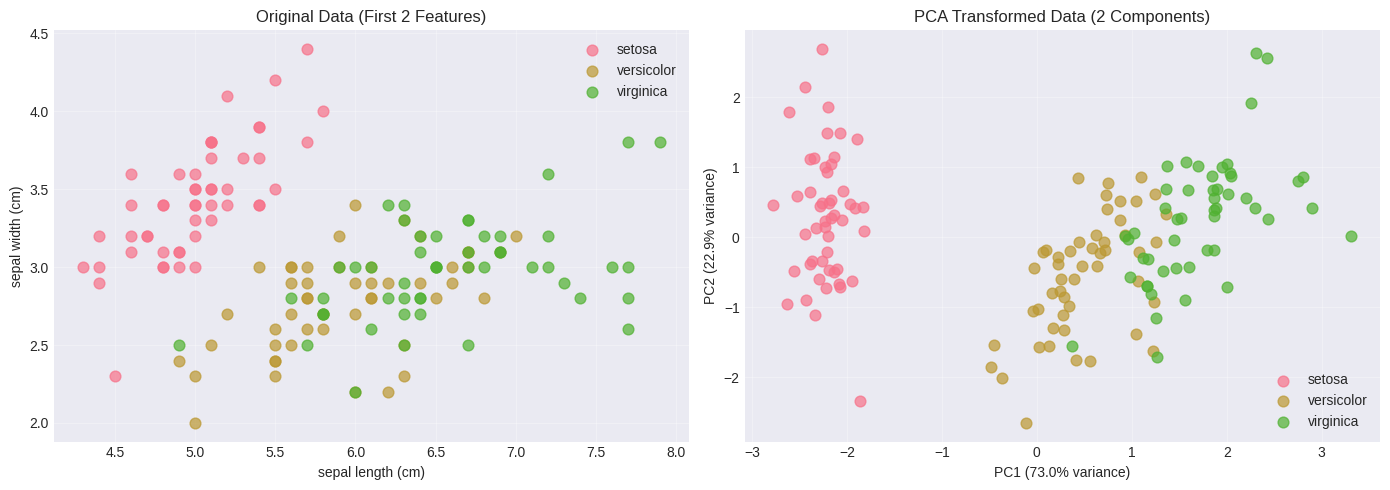

In [16]:
# Step 4: Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data (first 2 features only)
for i, target_name in enumerate(target_names):
    axes[0].scatter(X[y == i, 0], X[y == i, 1],
                    label=target_name, alpha=0.7, s=60)
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title('Original Data (First 2 Features)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PCA transformed data
for i, target_name in enumerate(target_names):
    axes[1].scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                    label=target_name, alpha=0.7, s=60)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('PCA Transformed Data (2 Components)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_iris_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_iris_comparison.png")


EXAMPLE 3: WINE DATASET (HIGHER DIMENSIONALITY)

Original data shape: (178, 13)
Number of features: 13

2D PCA - Variance explained: 55.41%
3D PCA - Variance explained: 66.53%

✓ Saved: pca_wine_analysis.png


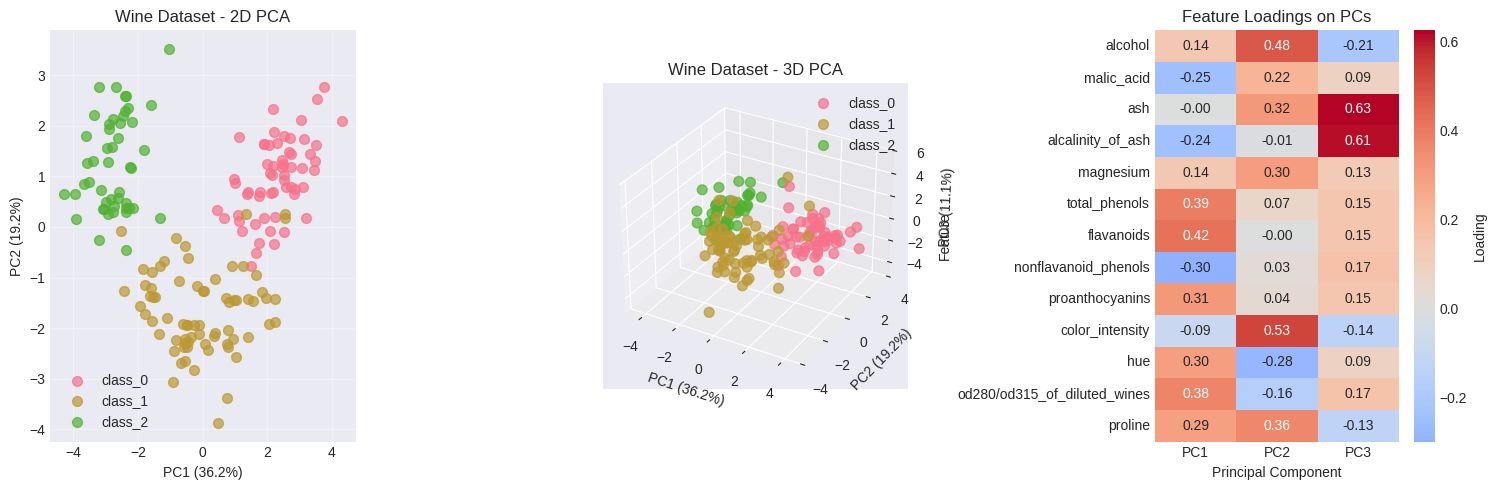

In [17]:
print("\n" + "="*80)
print("EXAMPLE 3: WINE DATASET (HIGHER DIMENSIONALITY)")
print("="*80)

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(f"\nOriginal data shape: {X_wine.shape}")
print(f"Number of features: {len(wine.feature_names)}")

# Standardize
X_wine_scaled = StandardScaler().fit_transform(X_wine)

# PCA to 2D and 3D
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

X_wine_2d = pca_2d.fit_transform(X_wine_scaled)
X_wine_3d = pca_3d.fit_transform(X_wine_scaled)

print(f"\n2D PCA - Variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"3D PCA - Variance explained: {pca_3d.explained_variance_ratio_.sum():.2%}")

# Visualize
fig = plt.figure(figsize=(15, 5))

# 2D plot
ax1 = fig.add_subplot(131)
for i, target_name in enumerate(wine.target_names):
    ax1.scatter(X_wine_2d[y_wine == i, 0], X_wine_2d[y_wine == i, 1],
                label=target_name, alpha=0.7, s=50)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title('Wine Dataset - 2D PCA')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3D plot
ax2 = fig.add_subplot(132, projection='3d')
for i, target_name in enumerate(wine.target_names):
    ax2.scatter(X_wine_3d[y_wine == i, 0],
                X_wine_3d[y_wine == i, 1],
                X_wine_3d[y_wine == i, 2],
                label=target_name, alpha=0.7, s=50)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax2.set_title('Wine Dataset - 3D PCA')
ax2.legend()

# Feature importance heatmap
ax3 = fig.add_subplot(133)
components_wine = pd.DataFrame(
    pca_3d.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=wine.feature_names
)
sns.heatmap(components_wine, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax3, cbar_kws={'label': 'Loading'})
ax3.set_title('Feature Loadings on PCs')
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('pca_wine_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_wine_analysis.png")

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

print("="*100)
print(" "*30 + "ADVANCED PCA ANALYSIS WITH EDA")
print("="*100)


                              ADVANCED PCA ANALYSIS WITH EDA


In [20]:
# ============================================================================
# PART 1: DATA LOADING AND INITIAL EXPLORATION
# ============================================================================
print("\n" + "="*100)
print("PART 1: DATA LOADING & INITIAL EXPLORATION")
print("="*100)

# Load data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Create DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(f"\n📊 Dataset Overview:")
print(f"   • Samples: {X.shape[0]}")
print(f"   • Features: {X.shape[1]}")
print(f"   • Classes: {len(target_names)} ({', '.join(target_names)})")
print(f"   • Class distribution: {dict(pd.Series(y).value_counts())}")
print(f"   • Class balance: {y.mean():.1%} benign, {1-y.mean():.1%} malignant")

# Feature groups (the dataset has mean, SE, and worst for each measurement)
feature_groups = {
    'mean': [col for col in feature_names if 'mean' in col],
    'se': [col for col in feature_names if 'error' in col],
    'worst': [col for col in feature_names if 'worst' in col]
}

print(f"\n📋 Feature Groups:")
for group, features in feature_groups.items():
    print(f"   • {group.upper()}: {len(features)} features")

# Basic statistics
print(f"\n📈 Basic Statistics:")
print(df[feature_names].describe().iloc[[1, 2, 3, 5, 7]].T.to_string())



PART 1: DATA LOADING & INITIAL EXPLORATION

📊 Dataset Overview:
   • Samples: 569
   • Features: 30
   • Classes: 2 (malignant, benign)
   • Class distribution: {1: np.int64(357), 0: np.int64(212)}
   • Class balance: 62.7% benign, 37.3% malignant

📋 Feature Groups:
   • MEAN: 10 features
   • SE: 10 features
   • WORST: 10 features

📈 Basic Statistics:
                               mean         std         min         50%         max
mean radius               14.127292    3.524049    6.981000   13.370000    28.11000
mean texture              19.289649    4.301036    9.710000   18.840000    39.28000
mean perimeter            91.969033   24.298981   43.790000   86.240000   188.50000
mean area                654.889104  351.914129  143.500000  551.100000  2501.00000
mean smoothness            0.096360    0.014064    0.052630    0.095870     0.16340
mean compactness           0.104341    0.052813    0.019380    0.092630     0.34540
mean concavity             0.088799    0.079720    0.00


PART 2: EXPLORATORY DATA ANALYSIS - DISTRIBUTIONS & OUTLIERS

🔍 Data Quality Check:
   • Missing values: 0
   • Duplicate rows: 0
   • Data types: All numeric ✓
✓ Saved: 01_feature_distributions.png

📊 Normality Tests (Shapiro-Wilk, first 10 features):
Feature                        p-value      Normal?
-------------------------------------------------------
mean radius                    0.000000     ✗ No
mean texture                   0.000000     ✗ No
mean perimeter                 0.000000     ✗ No
mean area                      0.000000     ✗ No
mean smoothness                0.000086     ✗ No
mean compactness               0.000000     ✗ No
mean concavity                 0.000000     ✗ No
mean concave points            0.000000     ✗ No
mean symmetry                  0.000000     ✗ No
mean fractal dimension         0.000000     ✗ No

🎯 Outlier Analysis (IQR method):
                         Outlier Count  Percentage
area error                          65   11.423550
radius error

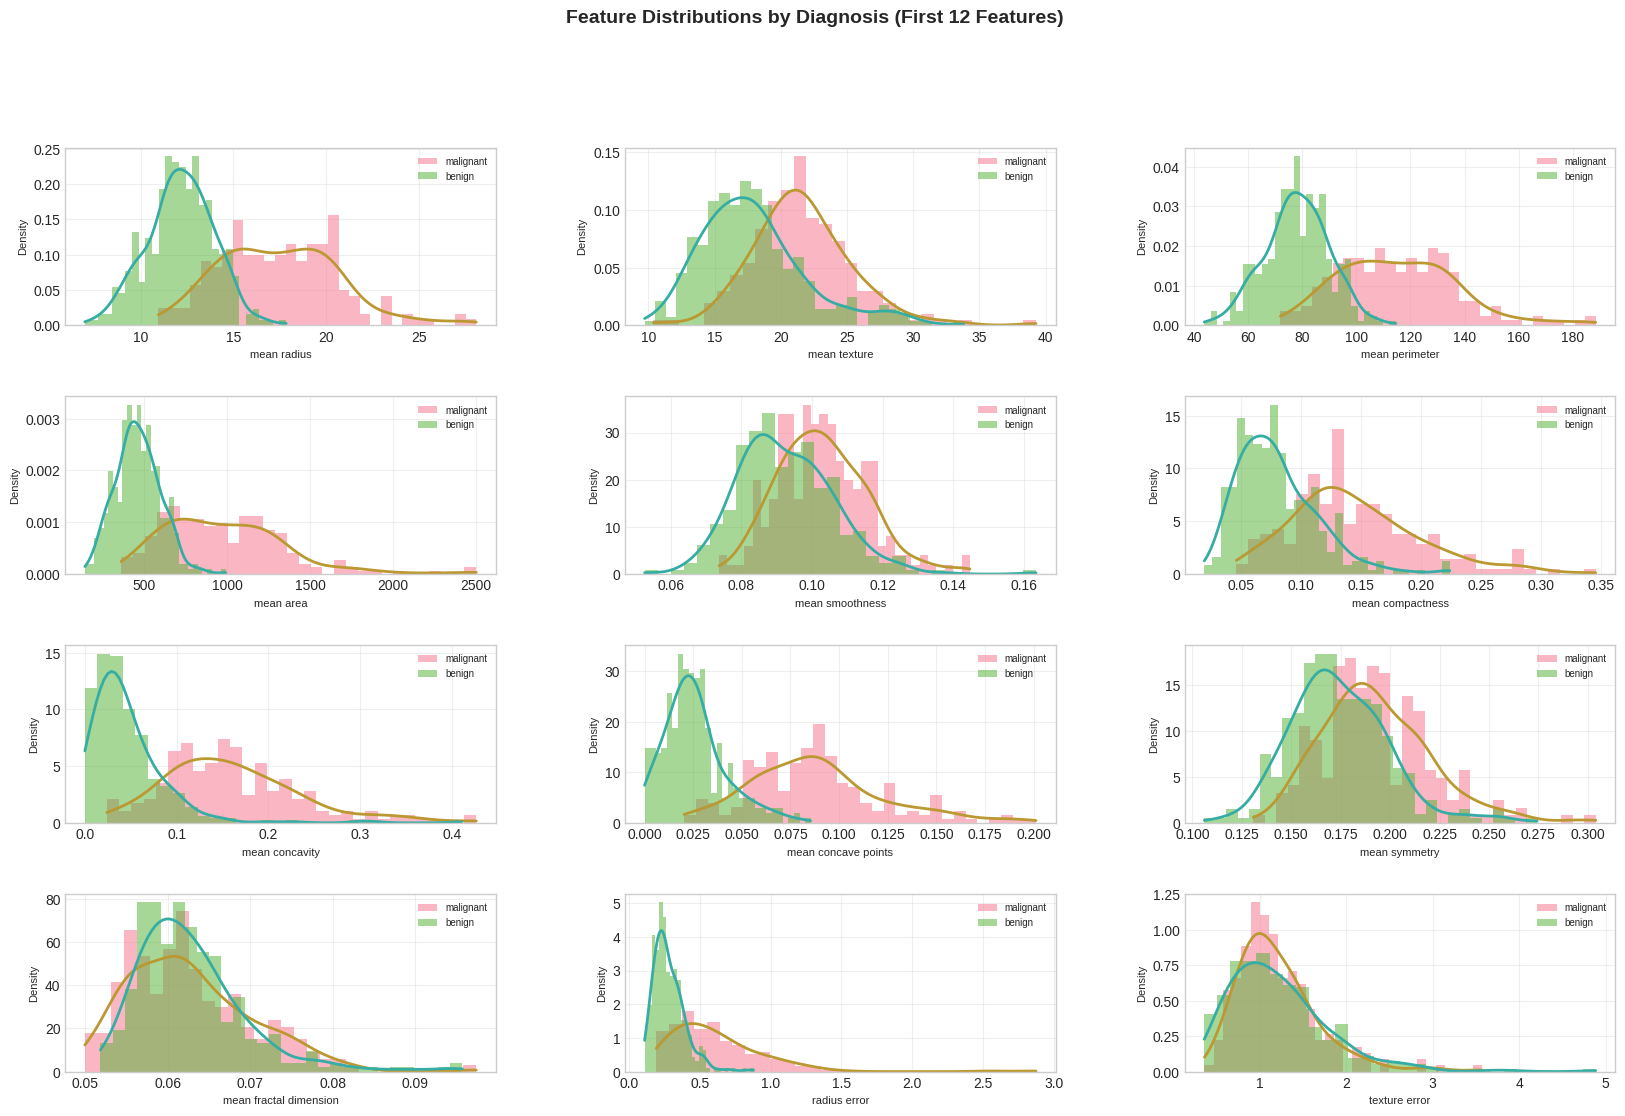

In [21]:
# ============================================================================
# PART 2: DEEP EDA - DISTRIBUTIONS AND OUTLIERS
# ============================================================================
print("\n" + "="*100)
print("PART 2: EXPLORATORY DATA ANALYSIS - DISTRIBUTIONS & OUTLIERS")
print("="*100)

# Check for missing values and data quality
print(f"\n🔍 Data Quality Check:")
print(f"   • Missing values: {df.isnull().sum().sum()}")
print(f"   • Duplicate rows: {df.duplicated().sum()}")
print(f"   • Data types: All numeric ✓")

# Analyze distributions
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# Plot distributions for first 12 features
for idx, feature in enumerate(feature_names[:12]):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])

    # Histogram with KDE
    for diagnosis in [0, 1]:
        data_subset = df[df['target'] == diagnosis][feature]
        ax.hist(data_subset, bins=30, alpha=0.5,
                label=target_names[diagnosis], density=True)

        # Add KDE
        kde_x = np.linspace(data_subset.min(), data_subset.max(), 100)
        kde = stats.gaussian_kde(data_subset)
        ax.plot(kde_x, kde(kde_x), linewidth=2)

    ax.set_xlabel(feature, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Diagnosis (First 12 Features)',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig('01_feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_feature_distributions.png")

# Statistical tests for normality
print(f"\n📊 Normality Tests (Shapiro-Wilk, first 10 features):")
print(f"{'Feature':<30} {'p-value':<12} {'Normal?'}")
print("-" * 55)
for feature in feature_names[:10]:
    statistic, p_value = stats.shapiro(df[feature].sample(min(5000, len(df))))
    is_normal = "✓ Yes" if p_value > 0.05 else "✗ No"
    print(f"{feature:<30} {p_value:<12.6f} {is_normal}")

# Outlier detection using IQR method
print(f"\n🎯 Outlier Analysis (IQR method):")
outlier_counts = {}
for feature in feature_names:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[feature] < (Q1 - 1.5 * IQR)) |
                (df[feature] > (Q3 + 1.5 * IQR))).sum()
    outlier_counts[feature] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index',
                                     columns=['Outlier Count'])
outlier_df['Percentage'] = (outlier_df['Outlier Count'] / len(df) * 100)
print(outlier_df.nlargest(10, 'Outlier Count').to_string())


PART 3: CORRELATION ANALYSIS

🔗 Highly Correlated Feature Pairs (|r| > 0.9):
          Feature 1            Feature 2  Correlation
        mean radius       mean perimeter     0.997855
       worst radius      worst perimeter     0.993708
        mean radius            mean area     0.987357
     mean perimeter            mean area     0.986507
       worst radius           worst area     0.984015
    worst perimeter           worst area     0.977578
       radius error      perimeter error     0.972794
     mean perimeter      worst perimeter     0.970387
        mean radius         worst radius     0.969539
     mean perimeter         worst radius     0.969476
        mean radius      worst perimeter     0.965137
          mean area         worst radius     0.962746
          mean area           worst area     0.959213
          mean area      worst perimeter     0.959120
       radius error           area error     0.951830
     mean perimeter           worst area     0.941550
    

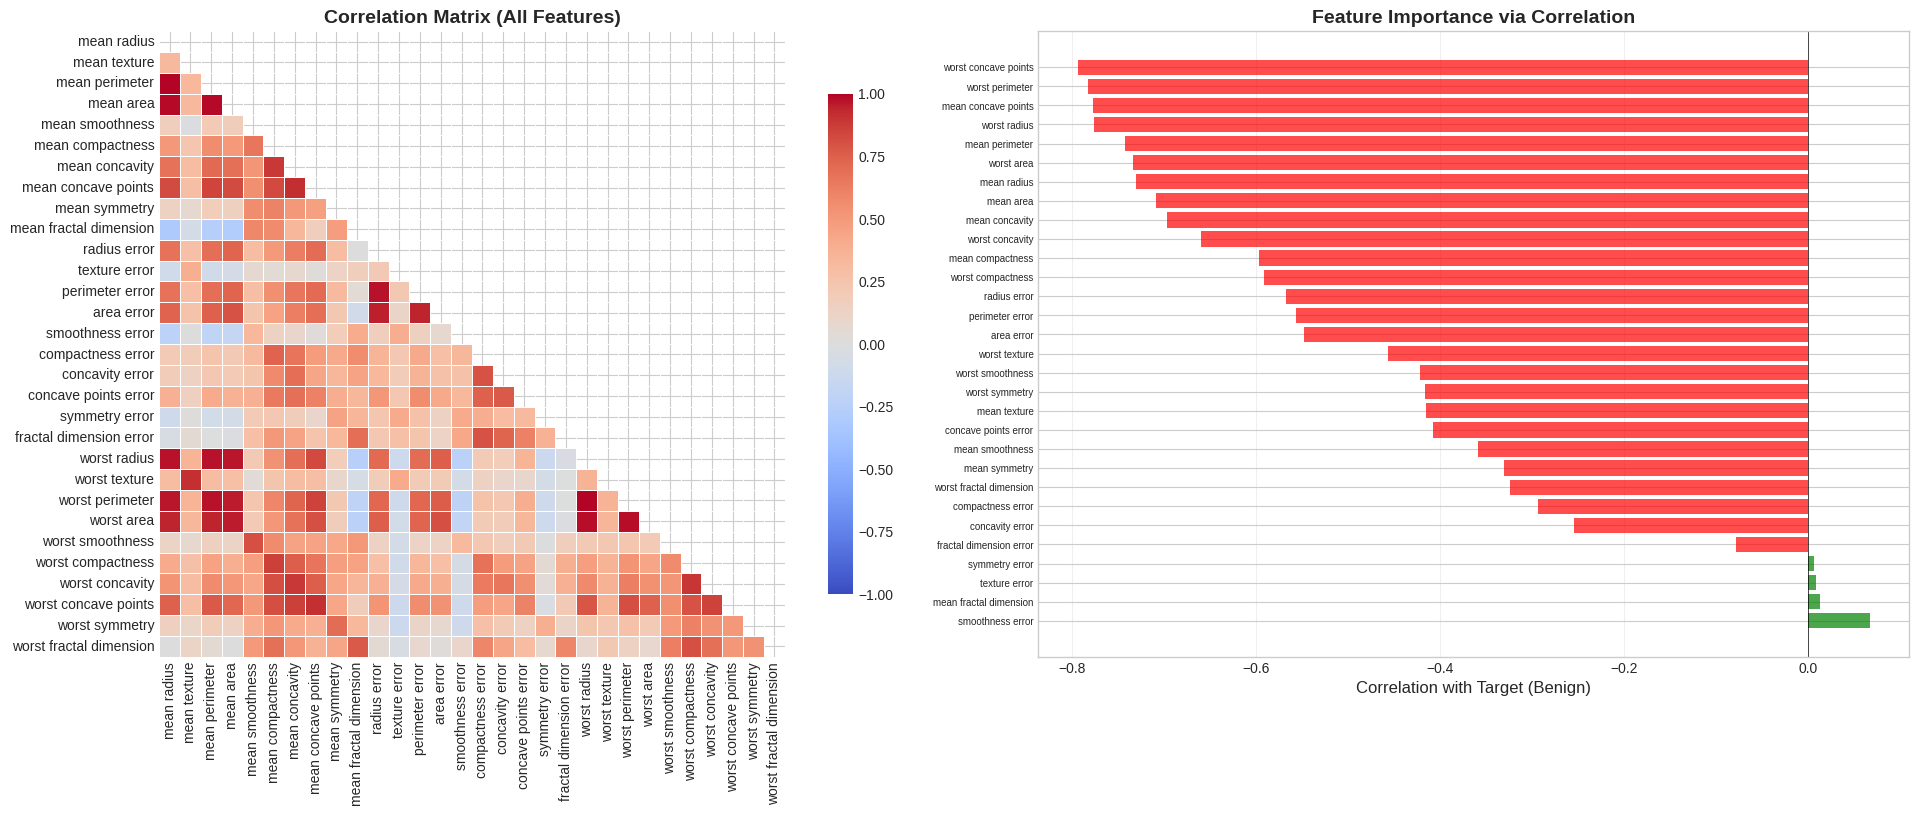

In [22]:
# ============================================================================
# PART 3: CORRELATION ANALYSIS
# ============================================================================
print("\n" + "="*100)
print("PART 3: CORRELATION ANALYSIS")
print("="*100)

# Compute correlation matrix
corr_matrix = df[feature_names].corr()

# Find highly correlated pairs
print(f"\n🔗 Highly Correlated Feature Pairs (|r| > 0.9):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation',
                                                          ascending=False)
print(high_corr_df.to_string(index=False))
print(f"\n   → Found {len(high_corr_pairs)} highly correlated pairs")
print(f"   → This suggests multicollinearity (PCA will help!)")

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix (All Features)',
                  fontsize=14, fontweight='bold')

# Correlation with target
target_corr = df[feature_names].corrwith(df['target']).sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
axes[1].barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)
axes[1].set_yticks(range(len(target_corr)))
axes[1].set_yticklabels(target_corr.index, fontsize=7)
axes[1].set_xlabel('Correlation with Target (Benign)', fontsize=12)
axes[1].set_title('Feature Importance via Correlation',
                  fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('02_correlation_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_correlation_analysis.png")

print(f"\n📌 Top 5 features correlated with benign diagnosis:")
for feature, corr in target_corr.head().items():
    print(f"   • {feature:<35} r = {corr:+.3f}")

In [23]:
print("\n" + "="*100)
print("PART 4: FEATURE SCALING ANALYSIS")
print("="*100)

# Analyze scale differences
print(f"\n📏 Feature Scale Comparison:")
scale_stats = df[feature_names].agg(['mean', 'std', 'min', 'max'])
scale_stats.loc['range'] = scale_stats.loc['max'] - scale_stats.loc['min']
print(scale_stats.T.nlargest(10, 'range')[['mean', 'std', 'range']].to_string())

print(f"\n⚠️  Scale Observations:")
print(f"   • Largest range: {scale_stats.loc['range'].max():.2f} ({scale_stats.loc['range'].idxmax()})")
print(f"   • Smallest range: {scale_stats.loc['range'].min():.2f} ({scale_stats.loc['range'].idxmin()})")
print(f"   • Range ratio: {scale_stats.loc['range'].max() / scale_stats.loc['range'].min():.0f}x difference!")
print(f"   → Standardization is ESSENTIAL for PCA")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify standardization
print(f"\n✓ After Standardization:")
print(f"   • Mean: {X_scaled.mean(axis=0).mean():.10f} ≈ 0")
print(f"   • Std:  {X_scaled.std(axis=0).mean():.10f} ≈ 1")


PART 4: FEATURE SCALING ANALYSIS

📏 Feature Scale Comparison:
                       mean         std     range
worst area       880.583128  569.356993  4068.800
mean area        654.889104  351.914129  2357.500
area error        40.337079   45.491006   535.398
worst perimeter  107.261213   33.602542   200.790
mean perimeter    91.969033   24.298981   144.710
worst texture     25.677223    6.146258    37.520
mean texture      19.289649    4.301036    29.570
worst radius      16.269190    4.833242    28.110
perimeter error    2.866059    2.021855    21.223
mean radius       14.127292    3.524049    21.129

⚠️  Scale Observations:
   • Largest range: 4068.80 (worst area)
   • Smallest range: 0.03 (fractal dimension error)
   • Range ratio: 140569x difference!
   → Standardization is ESSENTIAL for PCA

✓ After Standardization:
   • Mean: -0.0000000000 ≈ 0
   • Std:  1.0000000000 ≈ 1



PART 5: PRINCIPAL COMPONENT ANALYSIS

📊 Variance Explained Analysis:
PC     Variance     Cumulative   Description
----------------------------------------------------------------------
PC1    0.4427       0.4427       ← Primary variation
PC2    0.1897       0.6324       
PC3    0.0939       0.7264       
PC4    0.0660       0.7924       
PC5    0.0550       0.8473       
PC6    0.0402       0.8876       
PC7    0.0225       0.9101       ← 90% threshold
PC8    0.0159       0.9260       
PC9    0.0139       0.9399       
PC10   0.0117       0.9516       ← 95% threshold

🎯 Recommended Components:
   • For 90% variance: 7 components
   • For 95% variance: 10 components
   • Original dimensions: 30 features
   • Reduction: 66.7% fewer dimensions (95% variance)
✓ Saved: 03_variance_analysis.png


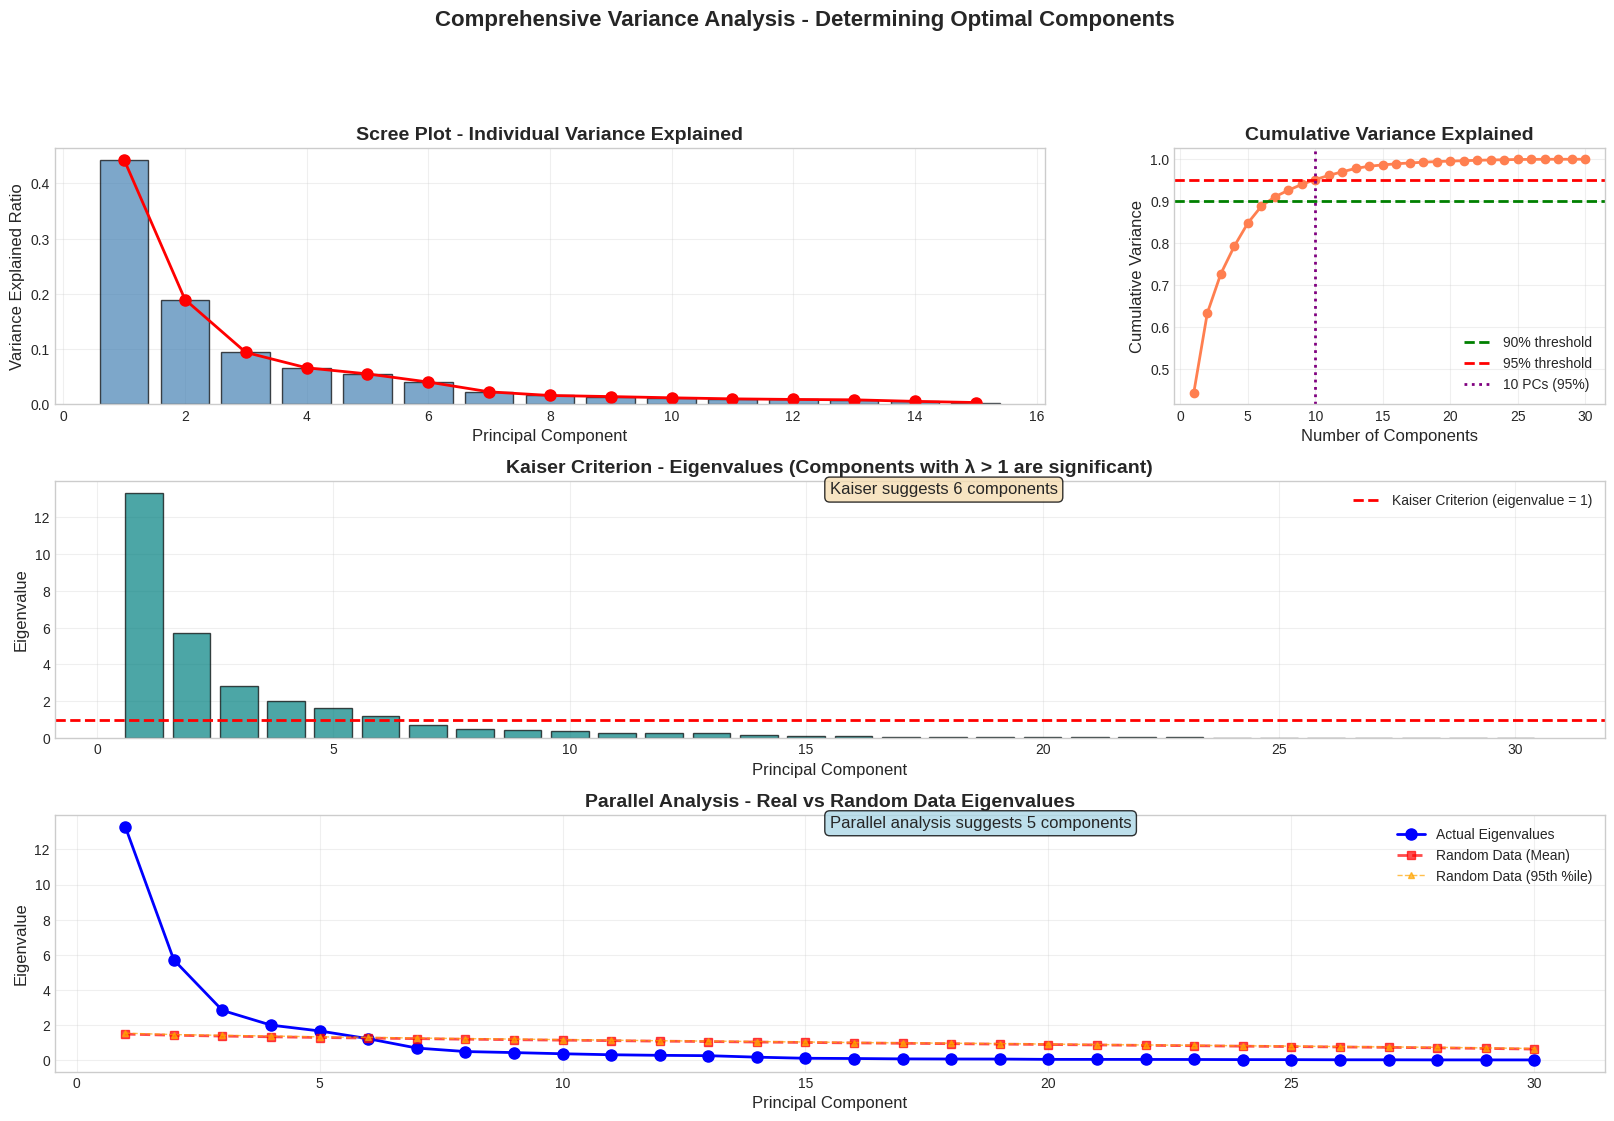

In [24]:
print("\n" + "="*100)
print("PART 5: PRINCIPAL COMPONENT ANALYSIS")
print("="*100)

# Fit PCA with all components
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Analyze explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

print(f"\n📊 Variance Explained Analysis:")
print(f"{'PC':<6} {'Variance':<12} {'Cumulative':<12} {'Description'}")
print("-" * 70)
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    var = pca_full.explained_variance_ratio_[i]
    cum_var = cumsum_var[i]

    if i == 0:
        desc = "← Primary variation"
    elif cum_var > 0.95 and cumsum_var[i-1] <= 0.95:
        desc = "← 95% threshold"
    elif cum_var > 0.90 and cumsum_var[i-1] <= 0.90:
        desc = "← 90% threshold"
    else:
        desc = ""

    print(f"PC{i+1:<4} {var:<12.4f} {cum_var:<12.4f} {desc}")

# Find optimal number of components
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

print(f"\n🎯 Recommended Components:")
print(f"   • For 90% variance: {n_components_90} components")
print(f"   • For 95% variance: {n_components_95} components")
print(f"   • Original dimensions: 30 features")
print(f"   • Reduction: {(1 - n_components_95/30)*100:.1f}% fewer dimensions (95% variance)")

# Detailed variance visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Scree plot
ax1 = fig.add_subplot(gs[0, :2])
ax1.bar(range(1, 16), pca_full.explained_variance_ratio_[:15],
        alpha=0.7, color='steelblue', edgecolor='black')
ax1.plot(range(1, 16), pca_full.explained_variance_ratio_[:15],
         'ro-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained Ratio', fontsize=12)
ax1.set_title('Scree Plot - Individual Variance Explained',
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Cumulative variance
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(range(1, len(cumsum_var) + 1), cumsum_var,
         'o-', linewidth=2, markersize=6, color='coral')
ax2.axhline(y=0.90, color='g', linestyle='--', label='90% threshold', linewidth=2)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold', linewidth=2)
ax2.axvline(x=n_components_95, color='purple', linestyle=':',
            label=f'{n_components_95} PCs (95%)', linewidth=2)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Kaiser criterion (eigenvalue > 1)
ax3 = fig.add_subplot(gs[1, :])
eigenvalues = pca_full.explained_variance_
ax3.bar(range(1, len(eigenvalues) + 1), eigenvalues, alpha=0.7,
        color='teal', edgecolor='black')
ax3.axhline(y=1, color='red', linestyle='--', linewidth=2,
            label='Kaiser Criterion (eigenvalue = 1)')
ax3.set_xlabel('Principal Component', fontsize=12)
ax3.set_ylabel('Eigenvalue', fontsize=12)
ax3.set_title('Kaiser Criterion - Eigenvalues (Components with λ > 1 are significant)',
              fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

n_kaiser = (eigenvalues > 1).sum()
ax3.text(0.5, 0.95, f'Kaiser suggests {n_kaiser} components',
         transform=ax3.transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 4. Parallel analysis simulation
np.random.seed(42)
n_iter = 100
random_eigenvalues = np.zeros((n_iter, X_scaled.shape[1]))
for i in range(n_iter):
    random_data = np.random.randn(*X_scaled.shape)
    random_pca = PCA()
    random_pca.fit(random_data)
    random_eigenvalues[i] = random_pca.explained_variance_

random_eigenvalues_mean = random_eigenvalues.mean(axis=0)
random_eigenvalues_95 = np.percentile(random_eigenvalues, 95, axis=0)

ax4 = fig.add_subplot(gs[2, :])
ax4.plot(range(1, len(eigenvalues) + 1), eigenvalues,
         'o-', linewidth=2, markersize=8, label='Actual Eigenvalues', color='blue')
ax4.plot(range(1, len(random_eigenvalues_mean) + 1), random_eigenvalues_mean,
         's--', linewidth=2, markersize=6, label='Random Data (Mean)', color='red', alpha=0.7)
ax4.plot(range(1, len(random_eigenvalues_95) + 1), random_eigenvalues_95,
         '^--', linewidth=1, markersize=5, label='Random Data (95th %ile)',
         color='orange', alpha=0.7)
ax4.set_xlabel('Principal Component', fontsize=12)
ax4.set_ylabel('Eigenvalue', fontsize=12)
ax4.set_title('Parallel Analysis - Real vs Random Data Eigenvalues',
              fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

n_parallel = (eigenvalues > random_eigenvalues_95).sum()
ax4.text(0.5, 0.95, f'Parallel analysis suggests {n_parallel} components',
         transform=ax4.transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('Comprehensive Variance Analysis - Determining Optimal Components',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('03_variance_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_variance_analysis.png")



PART 6: PRINCIPAL COMPONENT INTERPRETATION

📋 Component Loadings (Top 5 features per PC):

PC1 (explains 44.3% of variance):
Feature                                  Loading    Abs Loading
-----------------------------------------------------------------
mean concave points                      +0.2609    0.2609 ↑
mean concavity                           +0.2584    0.2584 ↑
worst concave points                     +0.2509    0.2509 ↑
mean compactness                         +0.2393    0.2393 ↑
worst perimeter                          +0.2366    0.2366 ↑

PC2 (explains 19.0% of variance):
Feature                                  Loading    Abs Loading
-----------------------------------------------------------------
mean fractal dimension                   +0.3666    0.3666 ↑
fractal dimension error                  +0.2801    0.2801 ↑
worst fractal dimension                  +0.2753    0.2753 ↑
mean radius                              -0.2339    0.2339 ↓
compactness error             

<Axes: title={'center': 'PC5 vs PC6'}, xlabel='PC5 (5.5%)', ylabel='PC6 (4.0%)'>

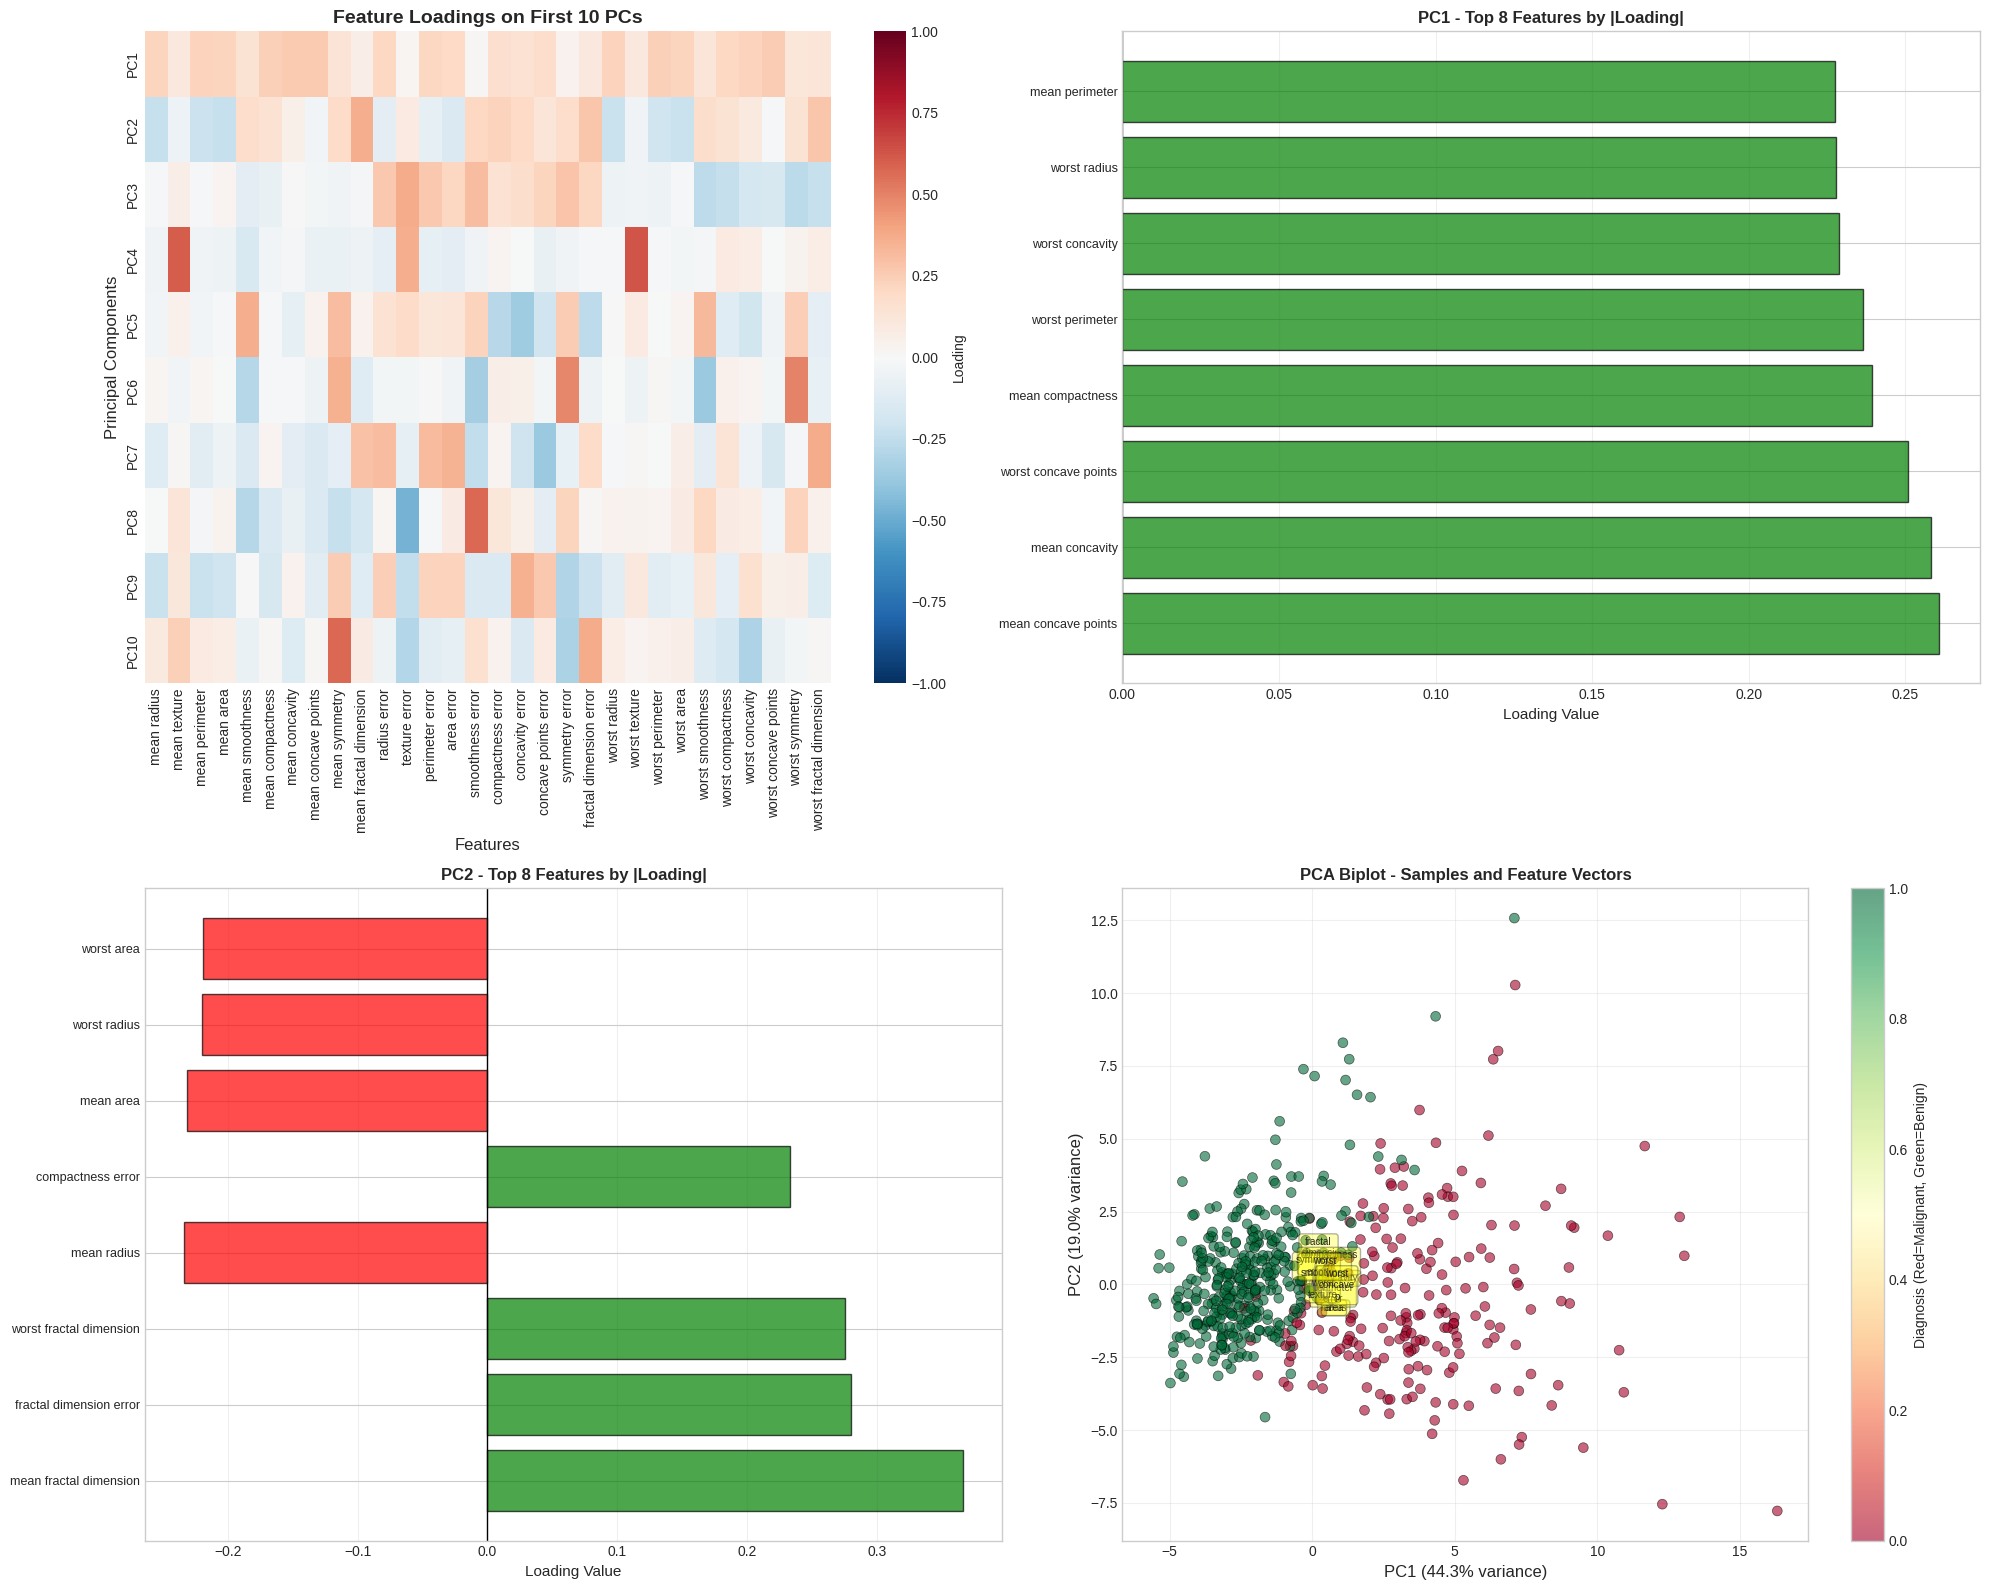

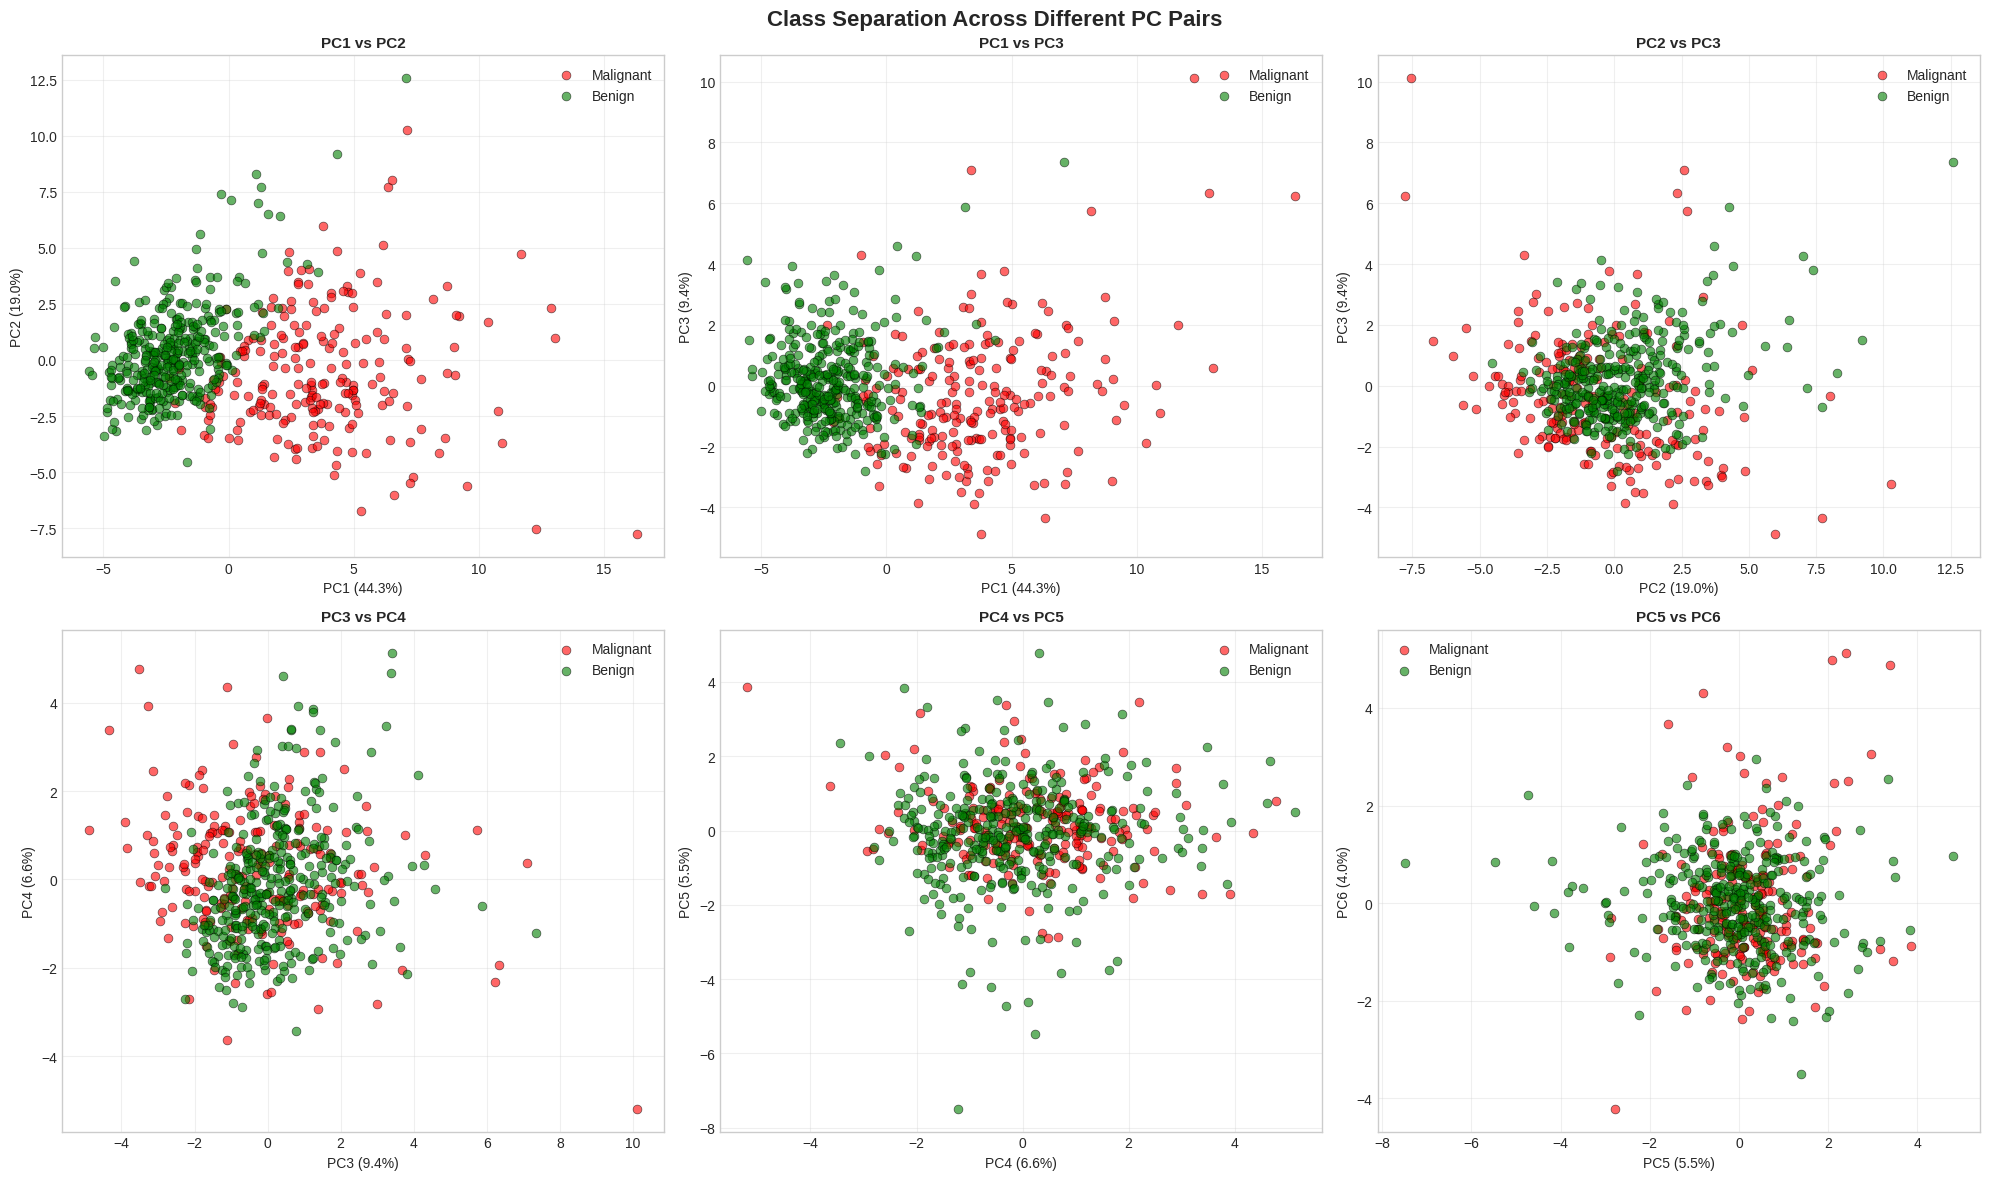

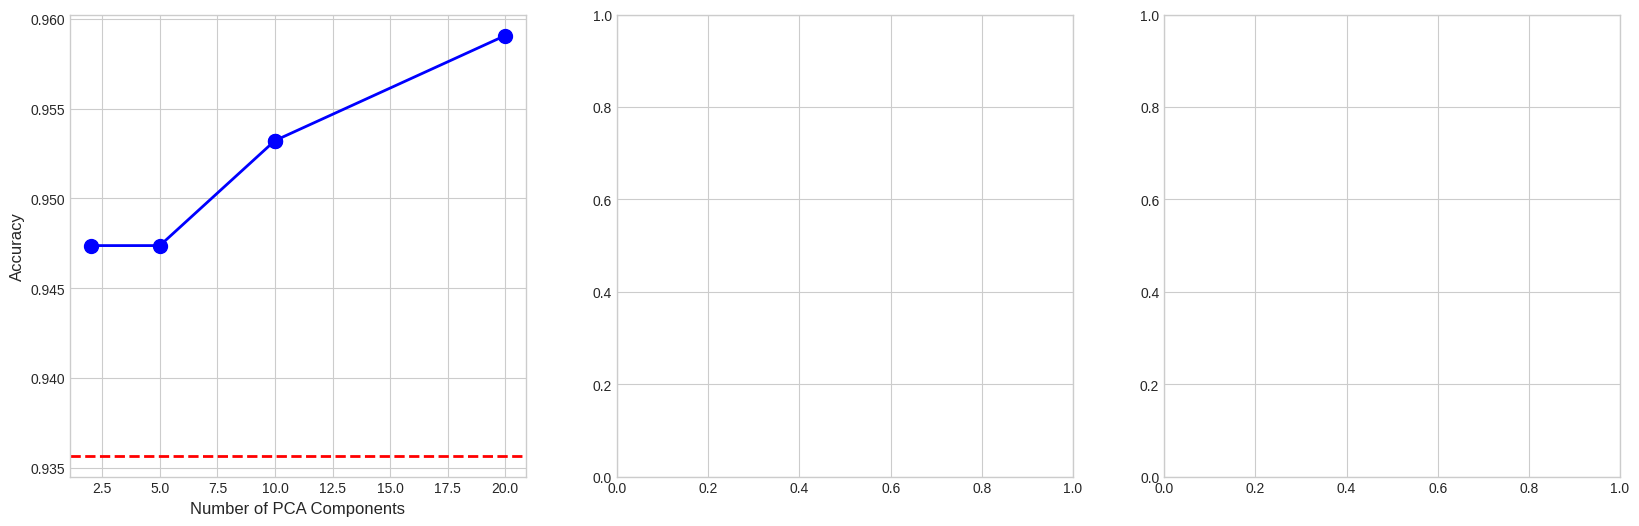

In [25]:
# ============================================================================
# PART 6: PRINCIPAL COMPONENT INTERPRETATION
# ============================================================================
print("\n" + "="*100)
print("PART 6: PRINCIPAL COMPONENT INTERPRETATION")
print("="*100)

# Use optimal number of components
n_components_optimal = n_components_95
pca = PCA(n_components=n_components_optimal)
X_pca = pca.fit_transform(X_scaled)

# Create loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)],
    index=feature_names
)

print(f"\n📋 Component Loadings (Top 5 features per PC):")
for i in range(min(5, n_components_optimal)):
    pc = f'PC{i+1}'
    print(f"\n{pc} (explains {pca.explained_variance_ratio_[i]:.1%} of variance):")
    print(f"{'Feature':<40} {'Loading':<10} {'Abs Loading'}")
    print("-" * 65)

    # Get top 5 by absolute value
    top_features = loadings[pc].abs().nlargest(5)
    for feature in top_features.index:
        loading = loadings.loc[feature, pc]
        abs_loading = abs(loading)
        direction = "↑" if loading > 0 else "↓"
        print(f"{feature:<40} {loading:+.4f}    {abs_loading:.4f} {direction}")

# Comprehensive loadings heatmap
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Full loadings heatmap
sns.heatmap(loadings.iloc[:, :10].T, cmap='RdBu_r', center=0,
            annot=False, cbar_kws={'label': 'Loading'},
            ax=axes[0, 0], vmin=-1, vmax=1)
axes[0, 0].set_title('Feature Loadings on First 10 PCs',
                     fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Features', fontsize=12)
axes[0, 0].set_ylabel('Principal Components', fontsize=12)

# 2. Top loadings per PC (first 5 PCs)
top_n = 8
for i in range(min(5, n_components_optimal)):
    pc = f'PC{i+1}'
    top_abs = loadings[pc].abs().nlargest(top_n)

    y_pos = np.arange(len(top_abs))
    colors = ['green' if loadings.loc[feat, pc] > 0 else 'red'
              for feat in top_abs.index]

    if i < 2:
        ax = axes[0, 1] if i == 0 else axes[1, 0]
        ax.barh(y_pos, [loadings.loc[feat, pc] for feat in top_abs.index],
                color=colors, alpha=0.7, edgecolor='black')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_abs.index, fontsize=9)
        ax.set_xlabel('Loading Value', fontsize=11)
        ax.set_title(f'{pc} - Top {top_n} Features by |Loading|',
                     fontsize=12, fontweight='bold')
        ax.axvline(x=0, color='black', linewidth=1)
        ax.grid(True, alpha=0.3, axis='x')

# 3. Biplot for PC1 and PC2
ax = axes[1, 1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                     cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Add feature vectors (loadings scaled for visibility)
scale_factor = 3
for i, feature in enumerate(feature_names[::3]):  # Every 3rd feature for clarity
    ax.arrow(0, 0,
             loadings.loc[feature, 'PC1'] * scale_factor,
             loadings.loc[feature, 'PC2'] * scale_factor,
             head_width=0.1, head_length=0.1, fc='blue', ec='blue',
             alpha=0.5, linewidth=1.5)
    ax.text(loadings.loc[feature, 'PC1'] * scale_factor * 1.15,
            loadings.loc[feature, 'PC2'] * scale_factor * 1.15,
            feature.replace('mean ', '').replace(' ', '\n')[:15],
            fontsize=7, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA Biplot - Samples and Feature Vectors', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Diagnosis (Red=Malignant, Green=Benign)', fontsize=10)

plt.tight_layout()
plt.savefig('04_component_interpretation.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_component_interpretation.png")

# ============================================================================
# PART 7: CLUSTERING IN PCA SPACE
# ============================================================================
print("\n" + "="*100)
print("PART 7: CLUSTERING ANALYSIS IN PCA SPACE")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot first 6 PC pairs
pc_pairs = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (4, 5)]
for idx, (pc1, pc2) in enumerate(pc_pairs):
    ax = axes[idx // 3, idx % 3]

    for target_val, color, name in zip([0, 1], ['red', 'green'],
                                        ['Malignant', 'Benign']):
        mask = y == target_val
        ax.scatter(X_pca[mask, pc1], X_pca[mask, pc2],
                   c=color, label=name, alpha=0.6, s=40, edgecolors='black', linewidth=0.5)

    ax.set_xlabel(f'PC{pc1+1} ({pca.explained_variance_ratio_[pc1]:.1%})', fontsize=10)
    ax.set_ylabel(f'PC{pc2+1} ({pca.explained_variance_ratio_[pc2]:.1%})', fontsize=10)
    ax.set_title(f'PC{pc1+1} vs PC{pc2+1}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Class Separation Across Different PC Pairs',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_pca_clustering.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 05_pca_clustering.png")

# Calculate separation metrics
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

print(f"\n📊 Clustering Quality Metrics:")
for n_comp in [2, 3, 5, n_components_optimal]:
    X_temp = X_pca[:, :n_comp]
    silhouette = silhouette_score(X_temp, y)

    # Calculate inter-class distance
    benign_center = X_temp[y == 1].mean(axis=0)
    malignant_center = X_temp[y == 0].mean(axis=0)
    inter_dist = np.linalg.norm(benign_center - malignant_center)

    print(f"   • {n_comp} components: Silhouette = {silhouette:.3f}, "
          f"Inter-class distance = {inter_dist:.2f}")

# ============================================================================
# PART 8: CLASSIFICATION COMPARISON (Original vs PCA)
# ============================================================================
print("\n" + "="*100)
print("PART 8: CLASSIFICATION PERFORMANCE - ORIGINAL VS PCA FEATURES")
print("="*100)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Train on original features
rf_original = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)
acc_original = (y_pred_original == y_test).mean()

print(f"\n🌳 Random Forest on Original Features (30D):")
print(f"   • Accuracy: {acc_original:.4f}")
print(classification_report(y_test, y_pred_original, target_names=target_names,
                           zero_division=0))

# Test different numbers of PCA components
results = []
for n_comp in [2, 5, 10, n_components_optimal, 20]:
    pca_temp = PCA(n_components=n_comp)
    X_train_pca = pca_temp.fit_transform(X_train)
    X_test_pca = pca_temp.transform(X_test)

    rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_pca.fit(X_train_pca, y_train)
    y_pred_pca = rf_pca.predict(X_test_pca)
    acc_pca = (y_pred_pca == y_test).mean()

    results.append({
        'n_components': n_comp,
        'accuracy': acc_pca,
        'variance_explained': pca_temp.explained_variance_ratio_.sum()
    })

    if n_comp == n_components_optimal:
        print(f"\n🌳 Random Forest on {n_comp} PCA Components:")
        print(f"   • Accuracy: {acc_pca:.4f}")
        print(f"   • Variance captured: {pca_temp.explained_variance_ratio_.sum():.1%}")
        print(classification_report(y_test, y_pred_pca, target_names=target_names,
                                   zero_division=0))

results_df = pd.DataFrame(results)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Accuracy vs number of components
ax1 = axes[0]
ax1.plot(results_df['n_components'], results_df['accuracy'],
         'o-', linewidth=2, markersize=10, color='blue', label='PCA Features')
ax1.axhline(y=acc_original, color='red', linestyle='--', linewidth=2,
            label=f'Original Features ({acc_original:.3f})')
ax1.set_xlabel('Number of PCA Components', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax